In [64]:
import pandas as pd
import json

In [65]:
from src.extract_scholar import (
    extract_google_scholar
)

from src.extract_pubmed import (
    extract_pubmed
)

from src.preprocess import (
    build_profile_text
)

from src.embeddings import (
    generate_embedding
)

import pandas as pd
import json

In [66]:
scholar_files = [
    "data/raw/scholar/_Andrew Ng_ - _Google Scholar_.html",
    "data/raw/scholar/_Li Fei-Fei_ - _Google Scholar_.html",
    "data/raw/scholar/_Yann LeCun_ - _Google Scholar_.html"
]

In [67]:
scholar_profiles = []

for file in scholar_files:

    profile = extract_google_scholar(file)

    scholar_profiles.append(profile)

scholar_profiles

[{'name': 'Andrew Ng',
  'affiliation': 'Stanford University',
  'research_interests': ['Machine Learning', 'Deep Learning', 'AI'],
  'publications': ['Latent dirichlet allocation',
   'ROS: an open-source Robot Operating System',
   'On spectral clustering: Analysis and an algorithm',
   'Recursive deep models for semantic compositionality over a sentiment treebank',
   'Rectifier nonlinearities improve neural network acoustic models',
   'Reading digits in natural images with unsupervised feature learning',
   'Learning word vectors for sentiment analysis',
   'An analysis of single-layer networks in unsupervised feature learning',
   'Large scale distributed deep networks',
   'Advances in neural information processing systems 22'],
  'citations': '316446',
  'h_index': '160',
  'i10_index': '382'},
 {'name': 'Li Fei-Fei',
  'affiliation': 'Professor of Computer Science, Stanford University',
  'research_interests': ['Artificial Intelligence',
   'Machine Learning',
   'Computer Vis

In [68]:
pubmed_files = [
    "data/raw/pubmed/andrew.html",
    "data/raw/pubmed/Fei-Fei-Li.html",
    "data/raw/pubmed/Yann LeCun.html"
]

In [69]:
pubmed_profiles = []

for file in pubmed_files:

    profile = extract_pubmed(file)

    pubmed_profiles.append(profile)

pubmed_profiles

[{'paper_title': 'Strain and serovar variants of Salmonella enterica exhibit diverse tolerance to food chain-related stress',
  'abstract': 'Non-Typhoidal Salmonella (NTS) continues to be a leading cause of foodborne illness worldwide. Food manufacturers implement hurdle technology by combining more than one approach to control food safety and quality, including preservatives such as organic acids, refrigeration, and heating. We assessed the variation in survival in stresses of genotypically diverse isolates of Salmonella enterica to identify genotypes with potential elevated risk to sub-optimal processing or cooking. Sub-lethal heat treatment, survival in desiccated conditions and growth in the presence of NaCl or organic acids were investigated. S. Gallinarum strain 287/91 was most sensitive to all stress conditions. While none of the strains replicated in a food matrix at 4 °C, S. Infantis strain S1326/28 retained the greatest viability, and six strains exhibited a significantly red

In [70]:
combined_profiles = []

for scholar, pubmed in zip(
    scholar_profiles,
    pubmed_profiles
):

    combined = {
        **scholar,
        **pubmed
    }

    combined_profiles.append(combined)

combined_profiles

[{'name': 'Andrew Ng',
  'affiliation': 'Stanford University',
  'research_interests': ['Machine Learning', 'Deep Learning', 'AI'],
  'publications': ['Latent dirichlet allocation',
   'ROS: an open-source Robot Operating System',
   'On spectral clustering: Analysis and an algorithm',
   'Recursive deep models for semantic compositionality over a sentiment treebank',
   'Rectifier nonlinearities improve neural network acoustic models',
   'Reading digits in natural images with unsupervised feature learning',
   'Learning word vectors for sentiment analysis',
   'An analysis of single-layer networks in unsupervised feature learning',
   'Large scale distributed deep networks',
   'Advances in neural information processing systems 22'],
  'citations': '316446',
  'h_index': '160',
  'i10_index': '382',
  'paper_title': 'Strain and serovar variants of Salmonella enterica exhibit diverse tolerance to food chain-related stress',
  'abstract': 'Non-Typhoidal Salmonella (NTS) continues to be

In [71]:
with open(
    "outputs/kol_profiles.json",
    "w"
) as f:

    json.dump(
        combined_profiles,
        f,
        indent=4
    )

print("JSON Saved Successfully")

JSON Saved Successfully


In [72]:
texts = []

for profile in combined_profiles:

    text = build_profile_text(profile)

    texts.append(text)

print(texts[0][:1000])

andrew ng stanford university machine learning deep learning ai latent dirichlet allocation ros an opensource robot operating system on spectral clustering analysis and an algorithm recursive deep models for semantic compositionality over a sentiment treebank rectifier nonlinearities improve neural network acoustic models reading digits in natural images with unsupervised feature learning learning word vectors for sentiment analysis an analysis of singlelayer networks in unsupervised feature learning large scale distributed deep networks advances in neural information processing systems 22 strain and serovar variants of salmonella enterica exhibit diverse tolerance to food chainrelated stress nontyphoidal salmonella nts continues to be a leading cause of foodborne illness worldwide food manufacturers implement hurdle technology by combining more than one approach to control food safety and quality including preservatives such as organic acids refrigeration and heating we assessed the v

In [73]:
embeddings = []

for text in texts:

    embedding = generate_embedding(text)

    embeddings.append(embedding)

print("Embeddings Generated")

Embeddings Generated


In [74]:
embeddings[0].shape

(384,)

In [75]:
from src.similarity import (
    compute_similarity_matrix
)

In [76]:
names = [
    p["name"]
    for p in combined_profiles
]

similarity_df = compute_similarity_matrix(
    embeddings,
    names
)

similarity_df

,Andrew Ng,Li Fei-Fei,Yann LeCun
Andrew Ng,1.000000,0.440475,0.359837
Li Fei-Fei,0.440475,1.000000,0.251877
Yann LeCun,0.359837,0.251877,1.000000


In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

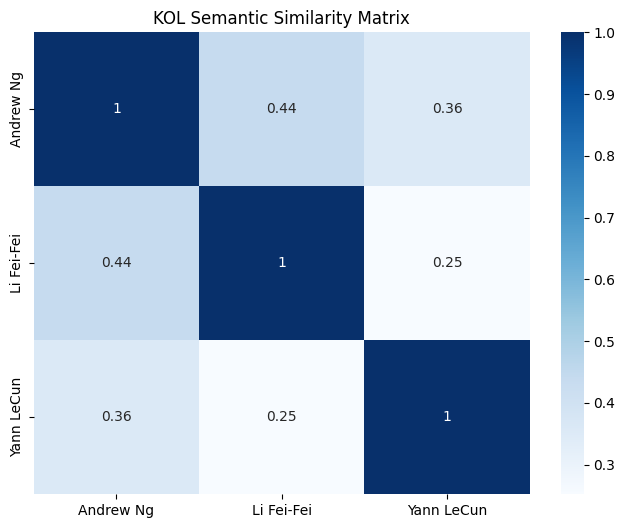

In [78]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    similarity_df,
    annot=True,
    cmap="Blues"
)

plt.title(
    "KOL Semantic Similarity Matrix"
)

plt.show()

In [79]:
from src.scoring import (
    calculate_influence_scores
)

In [80]:
scores = calculate_influence_scores(
    combined_profiles
)

scores

array([ 0.        , 41.11855282, 72.94117647])

In [81]:
for name, score in zip(
    names,
    scores
):

    print(
        f"{name}: {round(score, 2)}"
    )

Andrew Ng: 0.0
Li Fei-Fei: 41.12
Yann LeCun: 72.94


In [82]:
for profile in combined_profiles:

    print(profile["name"])

    print("Citations:", profile["citations"])

    print("H-index:", profile["h_index"])

    print("Publications:", len(profile["publications"]))

    print("-------------------")

Andrew Ng
Citations: 316446
H-index: 160
Publications: 10
-------------------
Li Fei-Fei
Citations: 351308
H-index: 177
Publications: 10
-------------------
Yann LeCun
Citations: 473220
H-index: 173
Publications: 10
-------------------


In [83]:
similarity_df.to_csv(
    "outputs/similarity_matrix.csv"
)

print("Similarity Matrix Saved")

Similarity Matrix Saved


In [84]:
import pandas as pd

score_df = pd.DataFrame({
    "Researcher": names,
    "Influence Score": scores
})

score_df.to_csv(
    "outputs/influence_scores.csv",
    index=False
)

score_df

,Researcher,Influence Score
0,Andrew Ng,0.000000
1,Li Fei-Fei,41.118553
2,Yann LeCun,72.941176


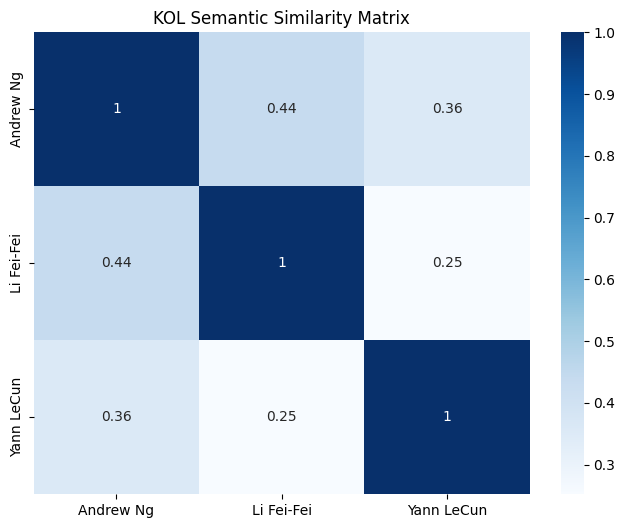

In [85]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    similarity_df,
    annot=True,
    cmap="Blues"
)

plt.title(
    "KOL Semantic Similarity Matrix"
)

plt.savefig(
    "outputs/similarity_heatmap.png"
)



In [86]:
from src.clustering import (
    cluster_kols
)

clusters = cluster_kols(
    embeddings
)

for name, cluster in zip(
    names,
    clusters
):

    print(
        f"{name} -> Cluster {cluster}"
    )

Andrew Ng -> Cluster 0
Li Fei-Fei -> Cluster 0
Yann LeCun -> Cluster 1


In [91]:
import importlib
import src.summarizer

importlib.reload(
    src.summarizer
)

<module 'src.summarizer' from 'c:\\Users\\LENOVO\\Desktop\\kol-ai-PROJECT\\src\\summarizer.py'>

In [93]:
from src.summarizer import (
    generate_llm_summary
)

In [94]:
summary = generate_llm_summary(
    combined_profiles,
    similarity_df
)

print(summary)

This analysis focuses on three prominent AI researchers, drawing insights from their profiles and a similarity matrix.

**1. Brief Summary of Each Researcher:**
*   **Andrew Ng:** A leading figure in Machine Learning and AI from Stanford University, known for contributions across deep learning, unsupervised learning, and robotics.
*   **Li Fei-Fei:** A Stanford professor specializing in AI, Machine Learning, and Computer Vision, notably for pioneering large-scale image datasets like ImageNet and visual-semantic AI.
*   **Yann LeCun:** An Executive Chairman at AMI Labs and NYU professor, recognized as a deep learning pioneer for his foundational work on convolutional networks and backpropagation.

**2. Most Similar Researcher Pair:**
Based on the similarity matrix, **Andrew Ng and Li Fei-Fei (0.440475)** are the most similar pair.

**3. Common Research Themes:**
All three researchers share core interests in **Artificial Intelligence, Machine Learning, and Deep Learning**. There's signif

In [95]:
with open(
    "outputs/llm_summary.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(summary)

print("Summary Saved")

Summary Saved
